<a href="https://colab.research.google.com/github/theodoral22/mnist-linear-classifiers/blob/main/linear_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Βιβλιοθήκες

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Φόρτωση Δεδομένων

In [ ]:
print('Φόρτωση δεδομένων MNIST')

#κατεβάζουμε το dataset
#mnist_784: το όνομα της βάσης
#as_frame=False: επιστρέφει τα δεδομένα σε μορφή πιμνάκων Numpy
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

#X: περιέχει τις εικόνες (784 pixels για κάθε εικόνα)
#y: περιέχει τις ετικέτες (τον πραγματικό αριθμό που δείχνει η εικόνα)
X=mnist.data
y=mnist.target

print("Η λήψη ολοκληρώθηκε")
print("Διαστάσεις δεδομένων (εικόνες, pixels):", X.shape)
print("Διαστάσεις των ετικετών:", y.shape)

Φόρτωση δεδομένων MNIST


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:75: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


RemoteDisconnected: Remote end closed connection without response

# Προεπεξεργασία και Διαχωρισμός Δεδομένων

In [ ]:
#κανονικοποίηση
X=X/255.0

#διαχωρισμός (train split - test split)
#train_size=10000: κρατάμε 10000 εικόνες για εκπαίδευση
#test_size=2000: κρατάμε 2000 εικόνες για εξέταση
#random_state=42: τυχαιότητα
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=60000, test_size=10000, random_state=42)

# Σενάρια

In [ ]:
#Σενάριο Α: 1000 δείγματα ανά κλάση
#Σενάριο Β: 1000 δείγματα για μία κλάση (5), 50 δείγματα για τις υπόλοιπες

X_train_A=[]
y_train_A=[]

X_train_B=[]
y_train_B=[]

for num in range(10): #για κάθε ψηφίο 0..9
  count_A=0
  count_B=0
  for i in range(len(y_train)): #για κάθε στοιχείο του y_train
    if (y_train[i]==str(num)):
      #Σενάριο Α
      if (count_A<1000): #1000 δείγματα για κάθε κλάση
        X_train_A.append(X_train[i])
        y_train_A.append(y_train[i])
        count_A+=1

      #Σενάριο Β
      if (num==5 and count_B<1000): #1000 δείγματα για την κλάση 5
        X_train_B.append(X_train[i])
        y_train_B.append(y_train[i])
        count_B+=1
      elif (num!=5 and count_B<50): #50 δείγματα για τις υπόλοιπες κλάσεις
        X_train_B.append(X_train[i])
        y_train_B.append(y_train[i])
        count_B+=1

    #αν έχουμε μαζέψει τα απαιτούμενα δείγματα και για τα δύο σενάρια, σταματάμε
    if count_A==1000 and ((num==5 and count_B==1000) or (num!=5 and count_B==50)):
        break

X_train_A=np.array(X_train_A)
y_train_A=np.array(y_train_A)

X_train_B=np.array(X_train_B)
y_train_B=np.array(y_train_B)

# One Versus One

---
Συνάρτηση Εκπαίδευσης

---




In [ ]:
#συνάρτηση εκπαίδευσης
def training_ovo(X_train, y_train, a, epochs):
  np.random.seed(42) #κλειδώνει την τυχαιότητα
  ovo_models={} #εκπαιδευμένα βάρη κάθε ζευγαριού
  total_cost_history=[0]*epochs #κρατάει τα συνολικά λάθη ανά εποχή

  #προετοιμασία δεδομένων
  for class1 in range(9): #0..8
    for class2 in range(class1+1, 10): #class1+1..
      mask=(y_train==str(class1)) | (y_train==str(class2))
      X_pair=X_train[mask]
      y_pair=y_train[mask]
      y_binary=np.where(y_pair==str(class1), 1, -1) #αν y_pair ισούται με class1 βάλε 1, αλλιώς βάλε -1

      #εκπαίδευση
      w=np.zeros(784)
      b=0.0

      for epoch in range(epochs): #για καθε εποχή
        #ανακάτεμα
        indices=np.arange(len(X_pair))
        np.random.shuffle(indices)
        X_pair=X_pair[indices]
        y_binary=y_binary[indices]

        for x, y in zip(X_pair, y_binary): #για κάθε εικόνα (x) και ετικέτα (y)
          z=np.dot(w,x)+b ##z=w*x+b (np.dot: εσωτερικό γινόμενο w με x)
          if (y*z<=0): #λάθος
            w=w+a*y*x #w_new=w+ayx
            b=b+a*y #b_new=b+ay
            total_cost_history[epoch]+=1 #μετράμε το λάθος
      key=str(class1)+"_"+str(class2) #το κλειδί είναι της μορφής class1_class2 (πχ 3_8)
      ovo_models[key]=[w,b]

  return ovo_models, total_cost_history

---
Συνάρτηση Πρόβλεψης

---




In [ ]:
#συνάρτηση πρόβλεψης (ψηφοφορίας)
def prediction_ovo(ovo_models, X_test):
  predictions=[]

  for x in X_test: #για κάθε εικόνα
    votes=np.zeros(10) #μηδενίζω τις ψήφους
    for key in ovo_models.keys():
      w,b=ovo_models[key] #κρατάω βάρος και πόλωση
      class1,class2=key.split("_") #κρατάω τις κλάσεις
      score=np.dot(w,x)+b #ψήφος
      if (score>0): #ψήφισε την class1
        votes[int(class1)]+=1
      elif (score<0): #ψήφισε την class2
        votes[int(class2)]+=1
    predictions.append(np.argmax(votes))
  return predictions

---
Σενάριο Α

---




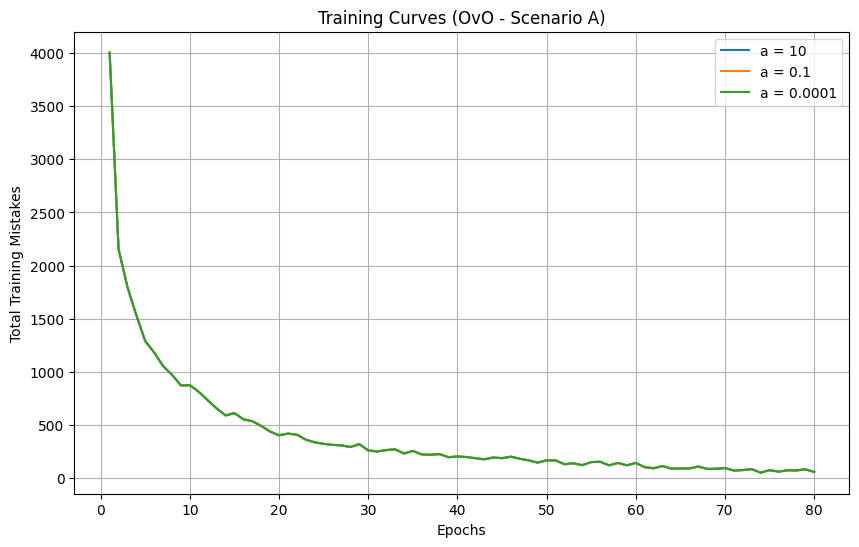

Learning rate: 10, Epochs: 5, Accuracy: 87.19%
Learning rate: 10, Epochs: 20, Accuracy: 90.91%
Learning rate: 10, Epochs: 80, Accuracy: 91.03%
Learning rate: 0.1, Epochs: 5, Accuracy: 87.19%
Learning rate: 0.1, Epochs: 20, Accuracy: 90.91%
Learning rate: 0.1, Epochs: 80, Accuracy: 91.03%
Learning rate: 0.0001, Epochs: 5, Accuracy: 87.19%
Learning rate: 0.0001, Epochs: 20, Accuracy: 90.91%
Learning rate: 0.0001, Epochs: 80, Accuracy: 91.03%


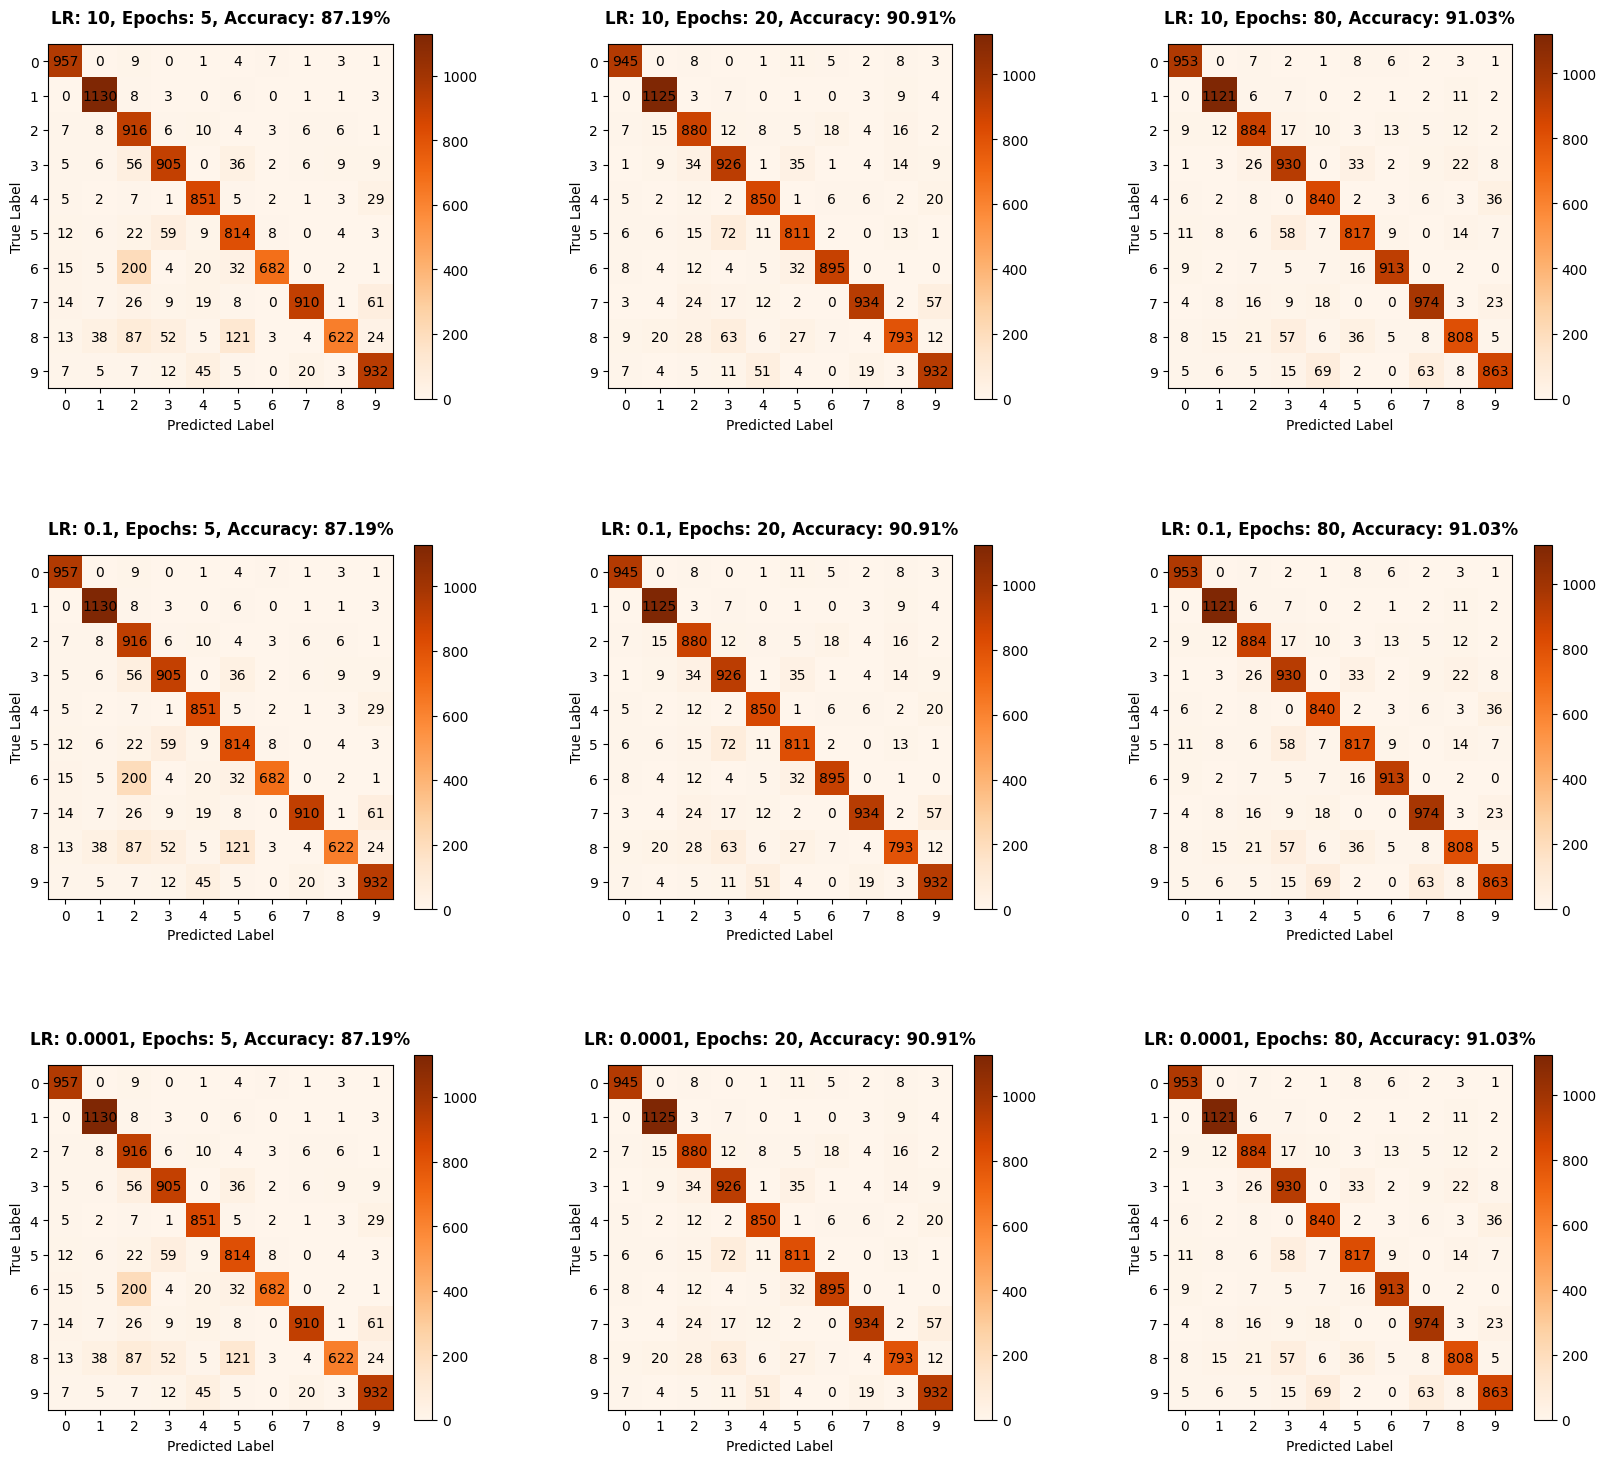

In [ ]:
#1. Παραγωγή Καμπυλών Εκπαίδευσης (Training Curves)
plt.figure(figsize=(10, 6))
learning_rates = [10, 0.1, 0.0001]

for a in learning_rates:
    _, cost_history = training_ovo(X_train_A, y_train_A, a=a, epochs=80)
    plt.plot(range(1, 81), cost_history, label=f'a = {a}')

plt.title("Training Curves (OvO - Scenario A)")
plt.xlabel("Epochs")
plt.ylabel("Total Training Mistakes")
plt.legend()
plt.grid(True)
plt.savefig("training_curves_ovo_A.png")
plt.show()


#2. Πίνακες Σύγχυσης & Αξιολόγηση (Grid Search)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους
epochs_list = [5, 20, 80]
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes_flat = axes.flatten()
plot_idx = 0

best_accuracy=0 #καλύτερο ποσοστό επιτυχίας
best_predictions=[] #καλύτερες προβλέψεις
best_params="" #καλύτερο learning rate και καλύτερο epochs

for a in learning_rates:
    for epochs in epochs_list:
        models, _ = training_ovo(X_train_A, y_train_A, a, epochs)
        predictions = prediction_ovo(models, X_test)

        #ποσοστά επιτυχίας
        correct=0
        for i in range(len(predictions)):
          if (predictions[i]==int(y_test_int[i])):
            correct+=1
        accuracy=(correct/len(predictions))*100
        print(f"Learning rate: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%")

        #κρατάμε το καλύτερο μοντέλο
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_predictions=predictions.copy()
            best_params=f"LR={a}, Epochs={epochs}"

        #πίνακες σύγχυσης
        confusion_matrix=np.zeros((10,10))

        for i in range(len(predictions)):
          true_val=y_test_int[i] #πραγματική τιμή
          pred_val=predictions[i] #προβλεπόμενη τιμή
          confusion_matrix[true_val][pred_val]+=1

        #δημιουργία γραφημάτων
        ax=axes_flat[plot_idx]
        im=ax.imshow(confusion_matrix, cmap='Oranges')

        title=f'LR: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%'
        ax.set_title(title, pad=15, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

        for row in range(10):
          for col in range(10):
            value=int(confusion_matrix[row,col])
            ax.text(col, row, value, va='center', ha='center')

        fig.colorbar(im, ax=ax)
        plot_idx+=1

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig("cm_ovo_A", dpi=300, bbox_inches='tight')
plt.show()

LR=10, Epochs=80


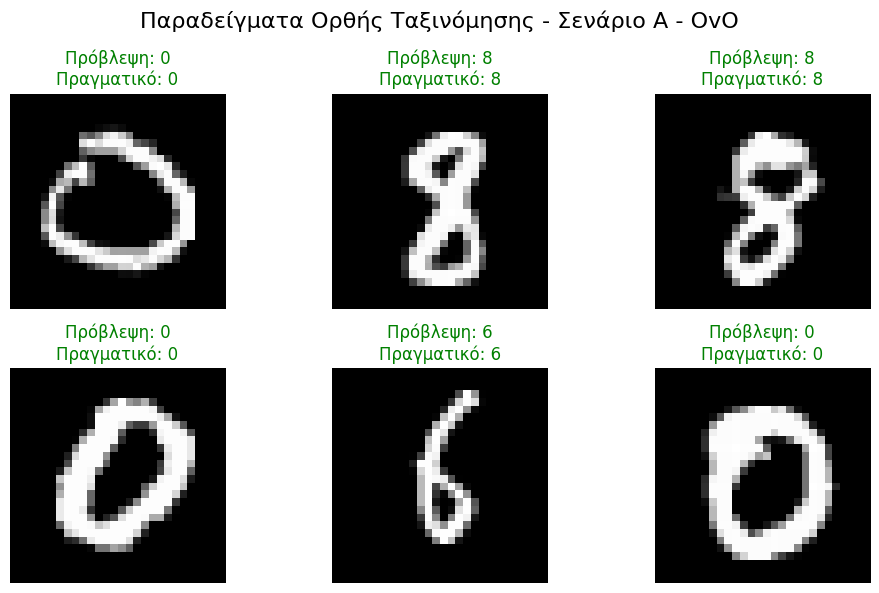

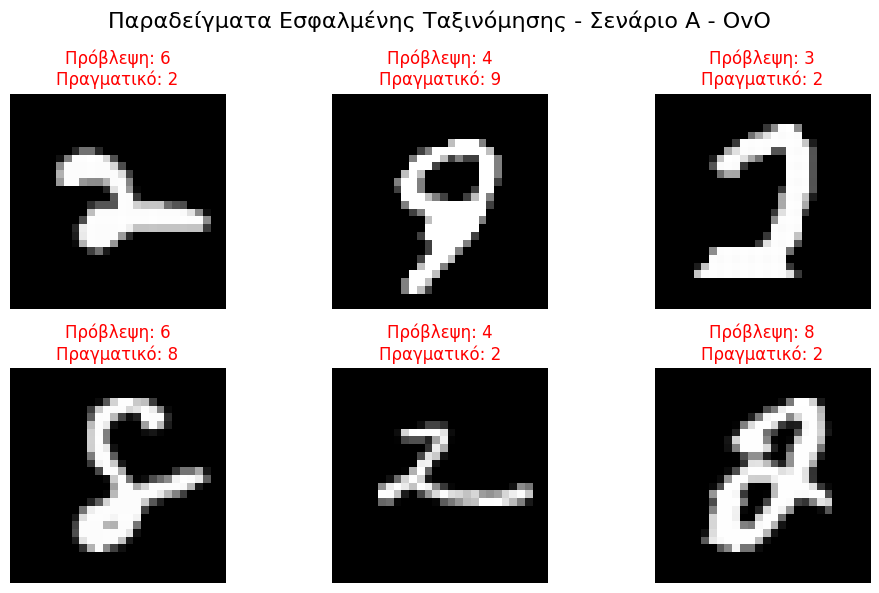

In [ ]:
#παραδείγματα ορθής και εσφαλμένης ταξινόμησης
print(best_params)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους

correct=[]
incorrect=[]

#διαχωρισμός δεικτών σε σωστά και λάθος
for i in range(len(best_predictions)):
    if best_predictions[i]==y_test_int[i]:
        correct.append(i)
    else:
        incorrect.append(i)

#επιλογή 6 τυχαίων παραδειγμάτων από κάθε κατηγορία
num_examples=6
np.random.seed(42) #κάθε φορά να βγάζει τα ίδια παραδείγματα
np.random.shuffle(correct)
np.random.shuffle(incorrect)

selected_correct=correct[:num_examples]
selected_incorrect=incorrect[:num_examples]

#ορθά παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Ορθής Ταξινόμησης - Σενάριο Α - OvO", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_correct):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="green")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("correct_ovo_A")
plt.show()

print("\n"+ " "*60+"\n")

#εσφαλμένα παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Εσφαλμένης Ταξινόμησης - Σενάριο Α - OvO", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_incorrect):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="red")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("incorrect_ovo_A")
plt.show()

---
Σενάριο Β

---




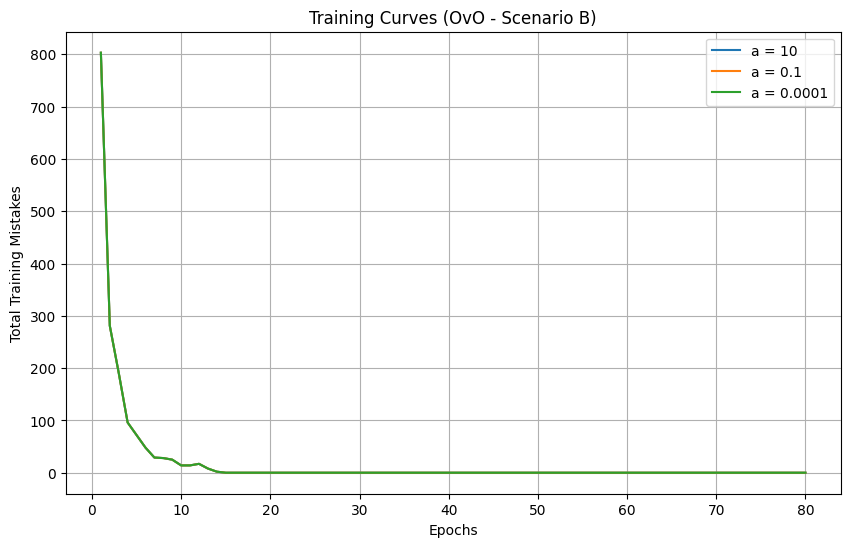

Learning rate: 10, Epochs: 5, Accuracy: 82.68%
Learning rate: 10, Epochs: 20, Accuracy: 81.93%
Learning rate: 10, Epochs: 80, Accuracy: 81.43%
Learning rate: 0.1, Epochs: 5, Accuracy: 82.68%
Learning rate: 0.1, Epochs: 20, Accuracy: 81.93%
Learning rate: 0.1, Epochs: 80, Accuracy: 81.43%
Learning rate: 0.0001, Epochs: 5, Accuracy: 82.68%
Learning rate: 0.0001, Epochs: 20, Accuracy: 81.93%
Learning rate: 0.0001, Epochs: 80, Accuracy: 81.43%


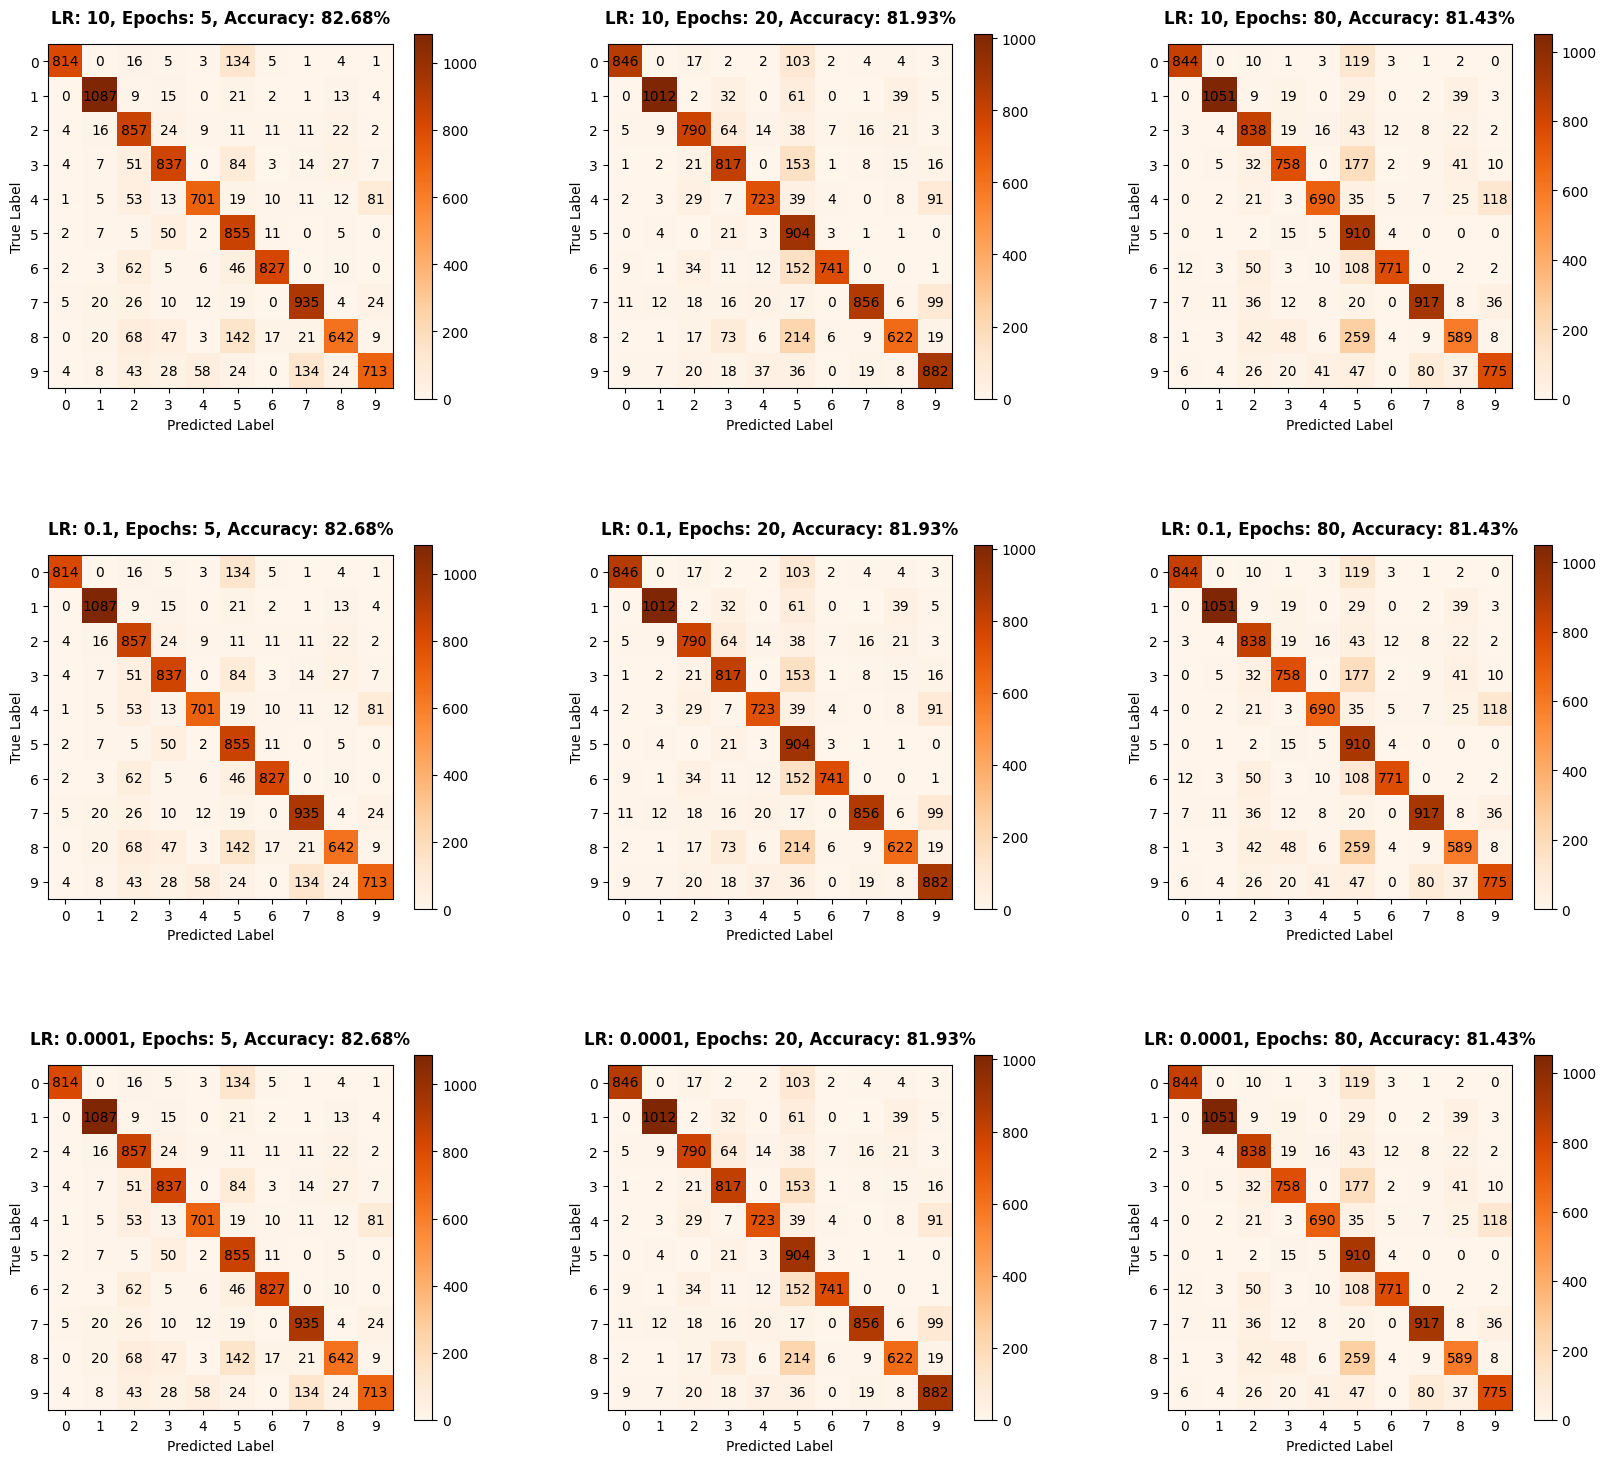

In [ ]:
# 1. Παραγωγή Καμπυλών Εκπαίδευσης (Training Curves)
plt.figure(figsize=(10, 6))
learning_rates = [10, 0.1, 0.0001]

for a in learning_rates:
    _, cost_history = training_ovo(X_train_B, y_train_B, a=a, epochs=80)
    plt.plot(range(1, 81), cost_history, label=f'a = {a}')

plt.title("Training Curves (OvO - Scenario B)")
plt.xlabel("Epochs")
plt.ylabel("Total Training Mistakes")
plt.legend()
plt.grid(True)
plt.savefig("training_curves_ovo_B.png")
plt.show()


# 2. Πίνακες Σύγχυσης & Αξιολόγηση (Grid Search)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους
epochs_list = [5, 20, 80]
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes_flat = axes.flatten()
plot_idx = 0

best_accuracy=0 #καλύτερο ποσοστό επιτυχίας
best_predictions=[] #καλύτερες προβλέψεις
best_params="" #καλύτερο learning rate και καλύτερο epochs

for a in learning_rates:
    for epochs in epochs_list:
        models, _ = training_ovo(X_train_B, y_train_B, a, epochs)
        predictions = prediction_ovo(models, X_test)

        #ποσοστά επιτυχίας
        correct=0
        for i in range(len(predictions)):
          if (predictions[i]==int(y_test_int[i])):
            correct+=1
        accuracy=(correct/len(predictions))*100
        print(f"Learning rate: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%")

        #κρατάμε το καλύτερο μοντέλο
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_predictions=predictions.copy()
            best_params=f"LR={a}, Epochs={epochs}"

        #πίνακες σύγχυσης
        confusion_matrix=np.zeros((10,10))

        for i in range(len(predictions)):
          true_val=y_test_int[i] #πραγματική τιμή
          pred_val=predictions[i] #προβλεπόμενη τιμή
          confusion_matrix[true_val][pred_val]+=1

        #δημιουργία γραφημάτων
        ax=axes_flat[plot_idx]
        im=ax.imshow(confusion_matrix, cmap='Oranges')

        title=f'LR: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%'
        ax.set_title(title, pad=15, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

        for row in range(10):
          for col in range(10):
            value=int(confusion_matrix[row,col])
            ax.text(col, row, value, va='center', ha='center')

        fig.colorbar(im, ax=ax)
        plot_idx+=1

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig("cm_ovo_B", dpi=300, bbox_inches='tight')
plt.show()

LR=10, Epochs=5


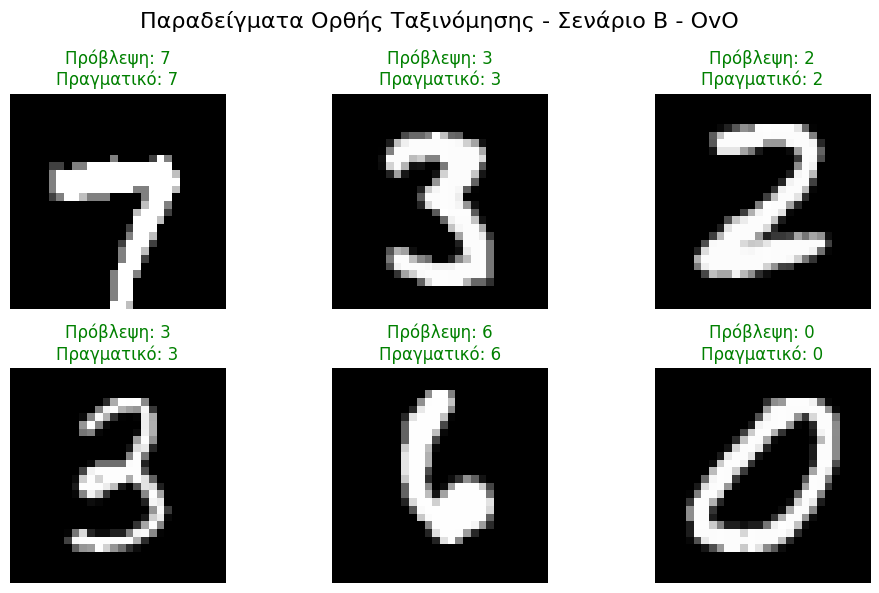

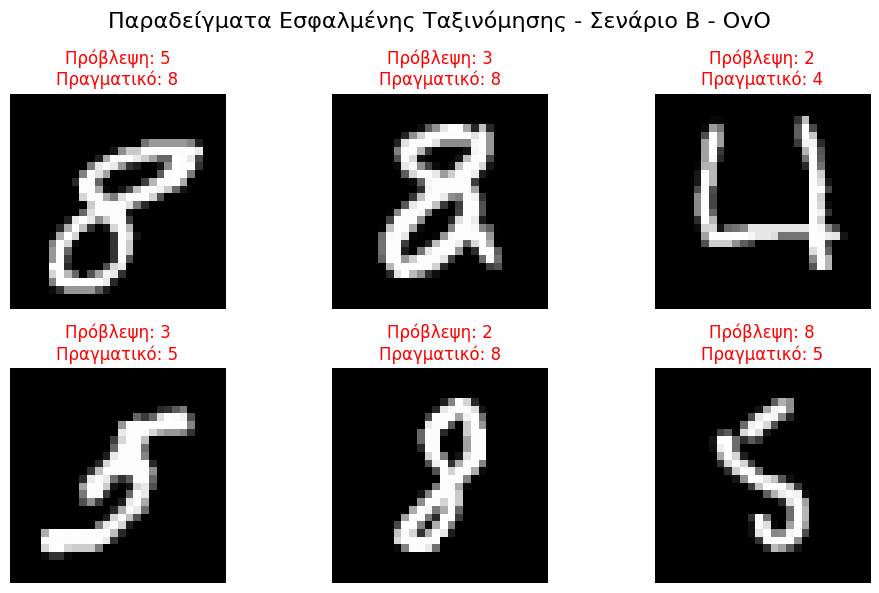

In [ ]:
#παραδείγματα ορθής και εσφαλμένης ταξινόμησης
print(best_params)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους

correct=[]
incorrect=[]

#διαχωρισμός δεικτών σε σωστά και λάθος
for i in range(len(best_predictions)):
    if best_predictions[i]==y_test_int[i]:
        correct.append(i)
    else:
        incorrect.append(i)

#επιλογή 6 τυχαίων παραδειγμάτων από κάθε κατηγορία
num_examples=6
np.random.seed(42) #κάθε φορά να βγάζει τα ίδια παραδείγματα
np.random.shuffle(correct)
np.random.shuffle(incorrect)

selected_correct=correct[:num_examples]
selected_incorrect=incorrect[:num_examples]

#ορθά παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Ορθής Ταξινόμησης - Σενάριο Β - OvO", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_correct):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="green")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("correct_ovo_B")
plt.show()

print("\n"+ " "*60+"\n")

#εσφαλμένα παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Εσφαλμένης Ταξινόμησης - Σενάριο Β - OvO", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_incorrect):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="red")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("incorrect_ovo_B")
plt.show()

# One Versus All



---
Συνάρτηση Εκπάιδευσης

---




In [ ]:
def training_ova(X_train, y_train, a, epochs):
  np.random.seed(42) #κλειδώνει την τυχαιότητα
  ova_models={} #εκπαιδευμένα βάρη κάθε ζευγαριού
  total_cost_history=[0]*epochs #κρατάει τα συνολικά λάθη ανά εποχή

  #προετοιμασία δεδομένων
  for target_class in range(10):
    y_binary=np.where(y_train==str(target_class), 1, -1)  #αν ισούται με target_class βάλε 1, αλλιώς βάλε -1

    #εκπαίδευση
    w=np.zeros(784)
    b=0.0

    for epoch in range(epochs): #για καθε εποχή
      #ανακάτεμα
      indices=np.arange(len(X_train))
      np.random.shuffle(indices)
      X_shuffled=X_train[indices]
      y_shuffled=y_binary[indices]

      for x, y in zip(X_shuffled, y_shuffled): #για κάθε εικόνα (x) και ετικέτα (y)
        z=np.dot(w,x)+b ##z=w*x+b (np.dot: εσωτερικό γινόμενο w με x)
        if (y*z<=0): #λάθος
          w=w+a*y*x #w_new=w+ayx
          b=b+a*y #b_new=b+ay
          total_cost_history[epoch]+=1 #μετράμε το λάθος
    ova_models[target_class]=[w,b]

  return ova_models, total_cost_history

---
Συνάρτηση Πρόβλεψης

---




In [ ]:
def prediction_ova(ova_models, X_test):
  predictions=[]

  for x in X_test: #για κάθε εικόνα
    votes=[]
    for target_class in range(10):
      w,b=ova_models[target_class] #κρατάω βάρος και πόλωση
      score=np.dot(w,x)+b #ψήφος
      votes.append(score)
    predictions.append(np.argmax(votes))
  return predictions

---
Σενάριο Α

---





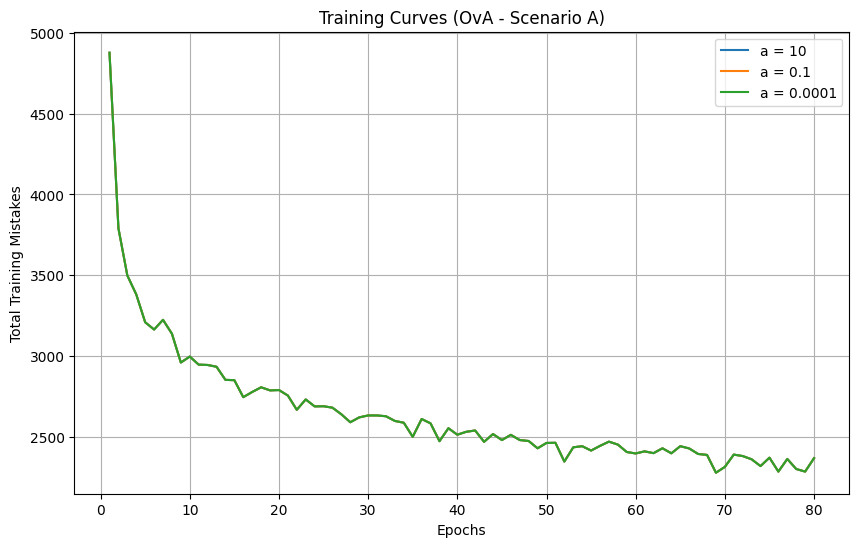

Learning rate: 10, Epochs: 5, Accuracy: 86.83%
Learning rate: 10, Epochs: 20, Accuracy: 86.75%
Learning rate: 10, Epochs: 80, Accuracy: 86.44%
Learning rate: 0.1, Epochs: 5, Accuracy: 86.83%
Learning rate: 0.1, Epochs: 20, Accuracy: 86.75%
Learning rate: 0.1, Epochs: 80, Accuracy: 86.44%
Learning rate: 0.0001, Epochs: 5, Accuracy: 86.83%
Learning rate: 0.0001, Epochs: 20, Accuracy: 86.75%
Learning rate: 0.0001, Epochs: 80, Accuracy: 86.44%


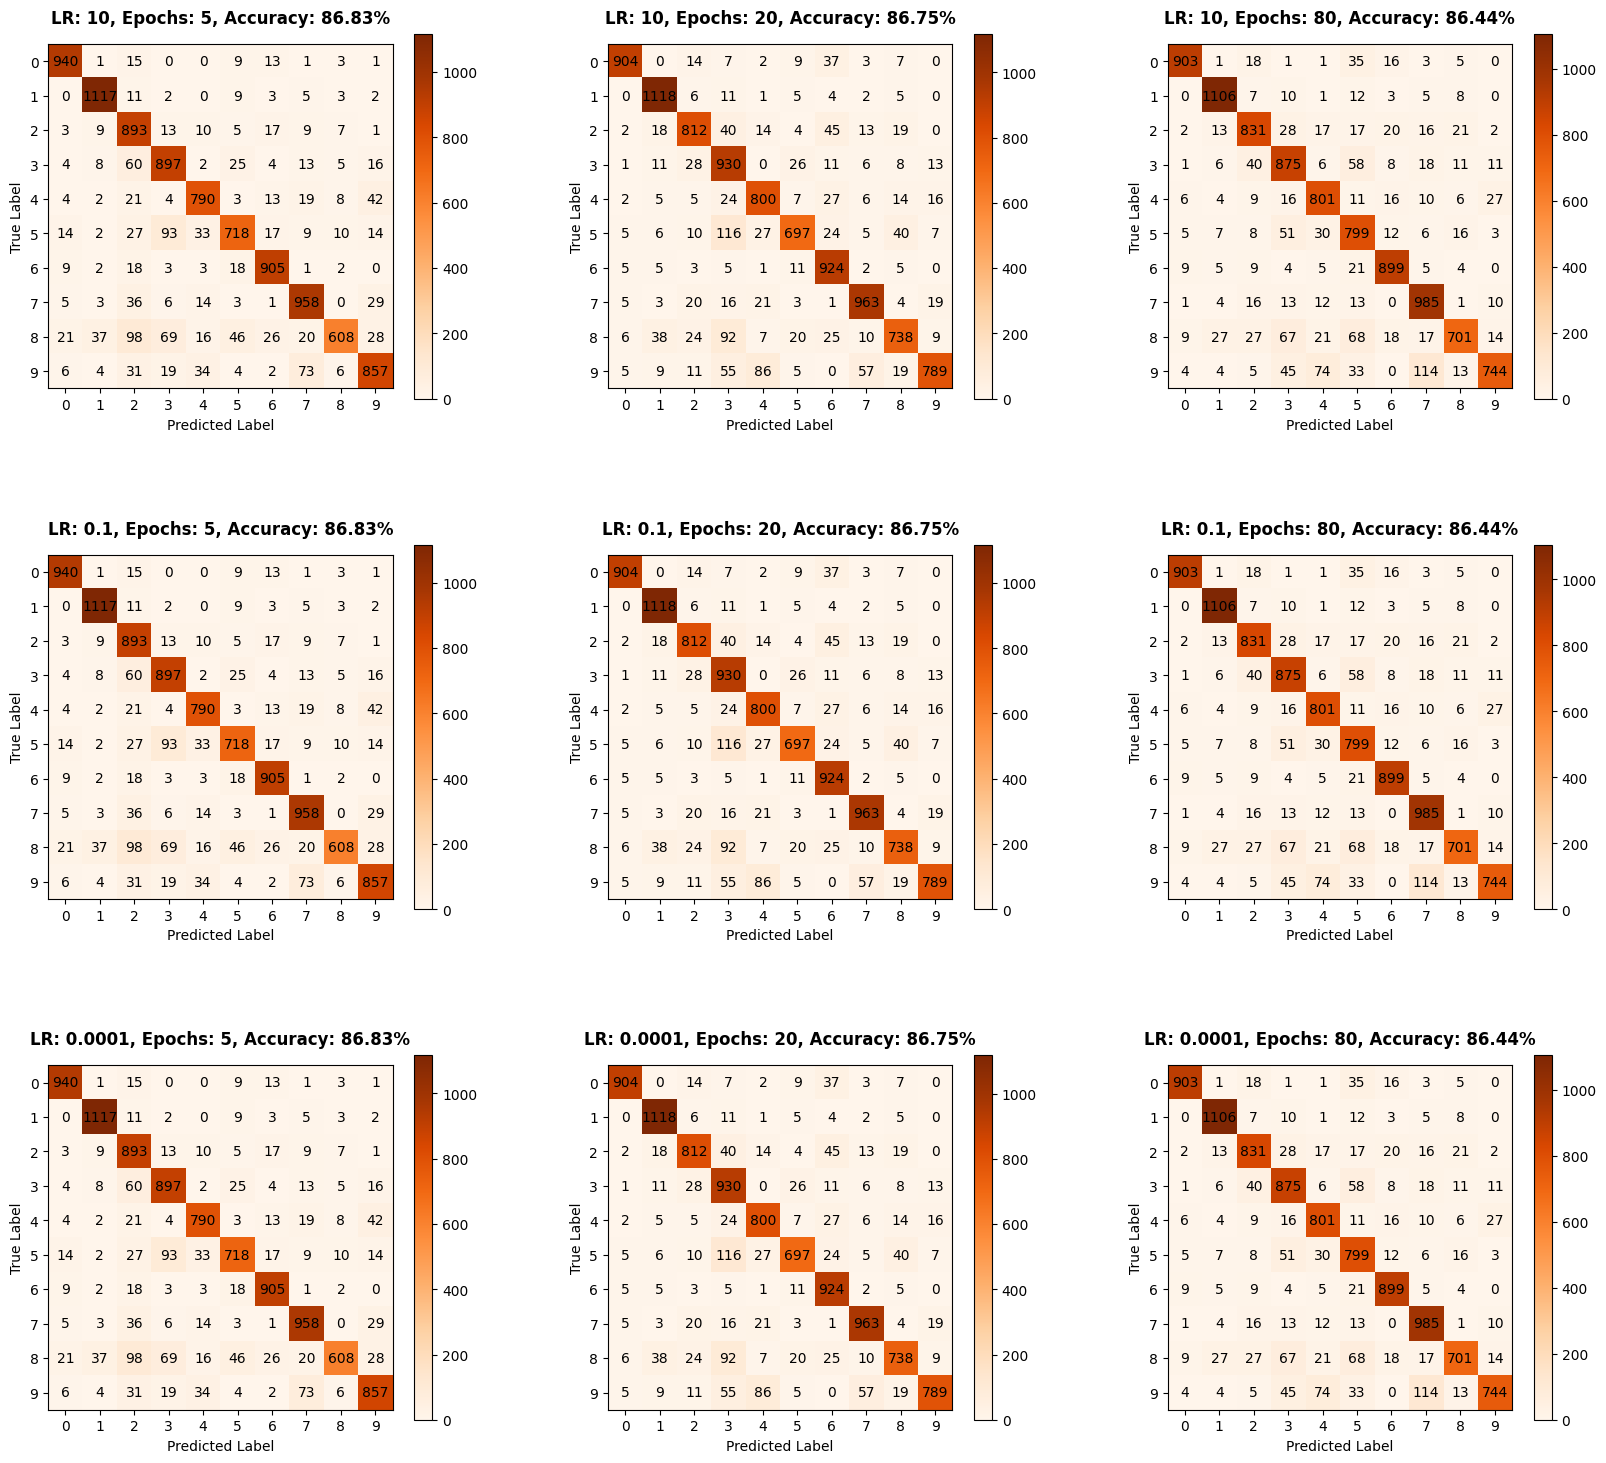

In [ ]:
# 1. Παραγωγή Καμπυλών Εκπαίδευσης (Training Curves)
plt.figure(figsize=(10, 6))
learning_rates = [10, 0.1, 0.0001]

for a in learning_rates:
    _, cost_history = training_ova(X_train_A, y_train_A, a=a, epochs=80)
    plt.plot(range(1, 81), cost_history, label=f'a = {a}')

plt.title("Training Curves (OvA - Scenario A)")
plt.xlabel("Epochs")
plt.ylabel("Total Training Mistakes")
plt.legend()
plt.grid(True)
plt.savefig("training_curves_ova_A.png")
plt.show()


# 2. Πίνακες Σύγχυσης & Αξιολόγηση (Grid Search)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους
epochs_list = [5, 20, 80]
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes_flat = axes.flatten()
plot_idx = 0

best_accuracy=0 #καλύτερο ποσοστό επιτυχίας
best_predictions=[] #καλύτερες προβλέψεις
best_params="" #καλύτερο learning rate και καλύτερο epochs

for a in learning_rates:
    for epochs in epochs_list:
        models, _ = training_ova(X_train_A, y_train_A, a, epochs)
        predictions = prediction_ova(models, X_test)

        #ποσοστά επιτυχίας
        correct=0
        for i in range(len(predictions)):
          if (predictions[i]==int(y_test_int[i])):
            correct+=1
        accuracy=(correct/len(predictions))*100
        print(f"Learning rate: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%")

        #κρατάμε το καλύτερο μοντέλο
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_predictions=predictions.copy()
            best_params=f"LR={a}, Epochs={epochs}"

        #πίνακες σύγχυσης
        confusion_matrix=np.zeros((10,10))

        for i in range(len(predictions)):
          true_val=y_test_int[i] #πραγματική τιμή
          pred_val=predictions[i] #προβλεπόμενη τιμή
          confusion_matrix[true_val][pred_val]+=1

        #δημιουργία γραφημάτων
        ax=axes_flat[plot_idx]
        im=ax.imshow(confusion_matrix, cmap='Oranges')

        title=f'LR: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%'
        ax.set_title(title, pad=15, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

        for row in range(10):
          for col in range(10):
            value=int(confusion_matrix[row,col])
            ax.text(col, row, value, va='center', ha='center')

        fig.colorbar(im, ax=ax)
        plot_idx+=1

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig("cm_ova_A", dpi=300, bbox_inches='tight')
plt.show()

LR=0.1, Epochs=80


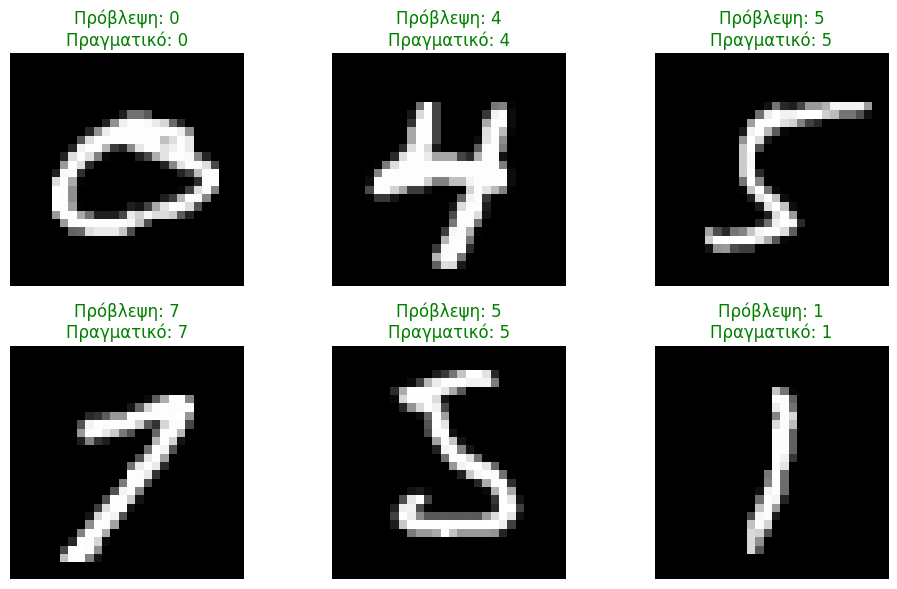

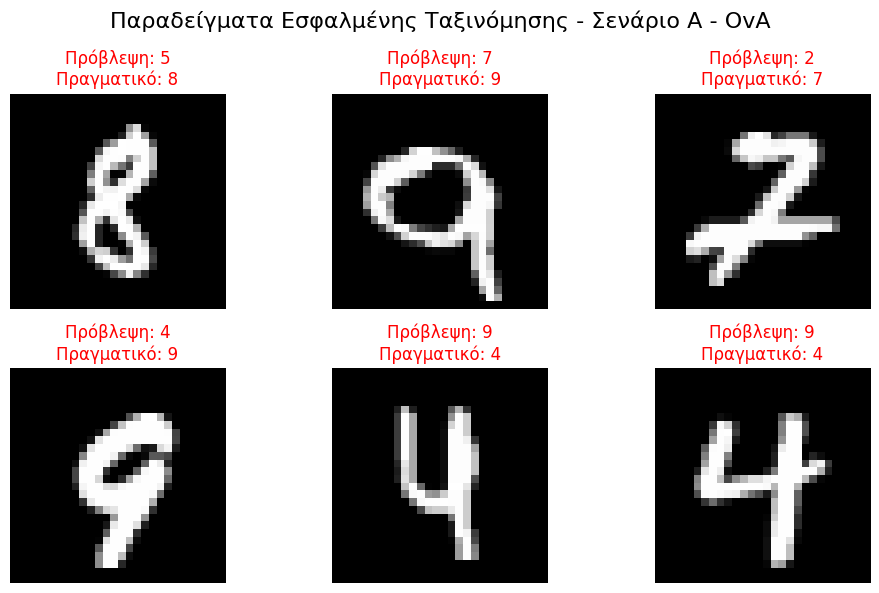

In [ ]:
#παραδείγματα ορθής και εσφαλμένης ταξινόμησης
print(best_params)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους

correct=[]
incorrect=[]

#διαχωρισμός δεικτών σε σωστά και λάθος
for i in range(len(best_predictions)):
    if best_predictions[i]==y_test_int[i]:
        correct.append(i)
    else:
        incorrect.append(i)

#επιλογή 6 τυχαίων παραδειγμάτων από κάθε κατηγορία
num_examples=6
np.random.seed(42) #κάθε φορά να βγάζει τα ίδια παραδείγματα
np.random.shuffle(correct)
np.random.shuffle(incorrect)

selected_correct=correct[:num_examples]
selected_incorrect=incorrect[:num_examples]

#ορθά παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Ορθής Ταξινόμησης - Σενάριο Α - OvA", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_correct):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="green")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("correct_ova_A")
plt.show()

print("\n"+ " "*60+"\n")

#εσφαλμένα παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Εσφαλμένης Ταξινόμησης - Σενάριο Α - OvA", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_incorrect):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="red")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("incorrect_ova_A")
plt.show()

---
Σενάριο Β

---





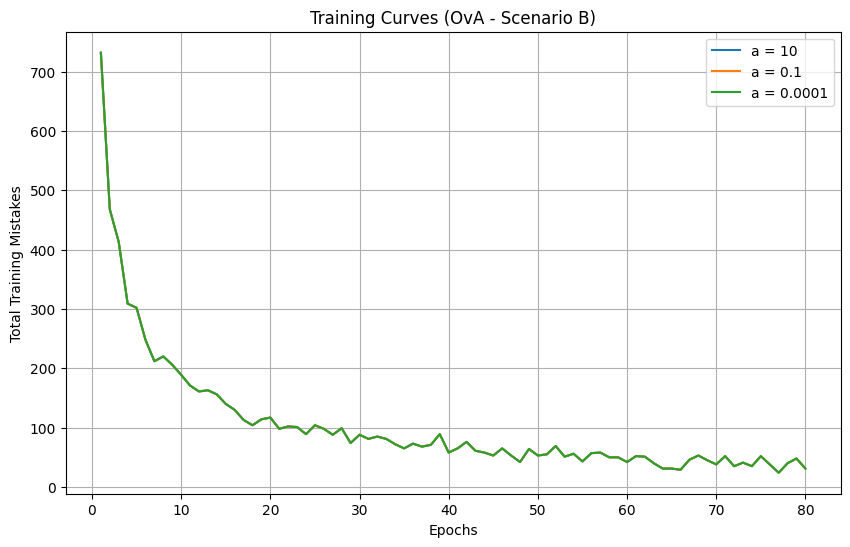

Learning rate: 10, Epochs: 5, Accuracy: 80.60%
Learning rate: 10, Epochs: 20, Accuracy: 77.92%
Learning rate: 10, Epochs: 80, Accuracy: 73.74%
Learning rate: 0.1, Epochs: 5, Accuracy: 80.60%
Learning rate: 0.1, Epochs: 20, Accuracy: 77.92%
Learning rate: 0.1, Epochs: 80, Accuracy: 73.74%
Learning rate: 0.0001, Epochs: 5, Accuracy: 80.60%
Learning rate: 0.0001, Epochs: 20, Accuracy: 77.92%
Learning rate: 0.0001, Epochs: 80, Accuracy: 73.74%


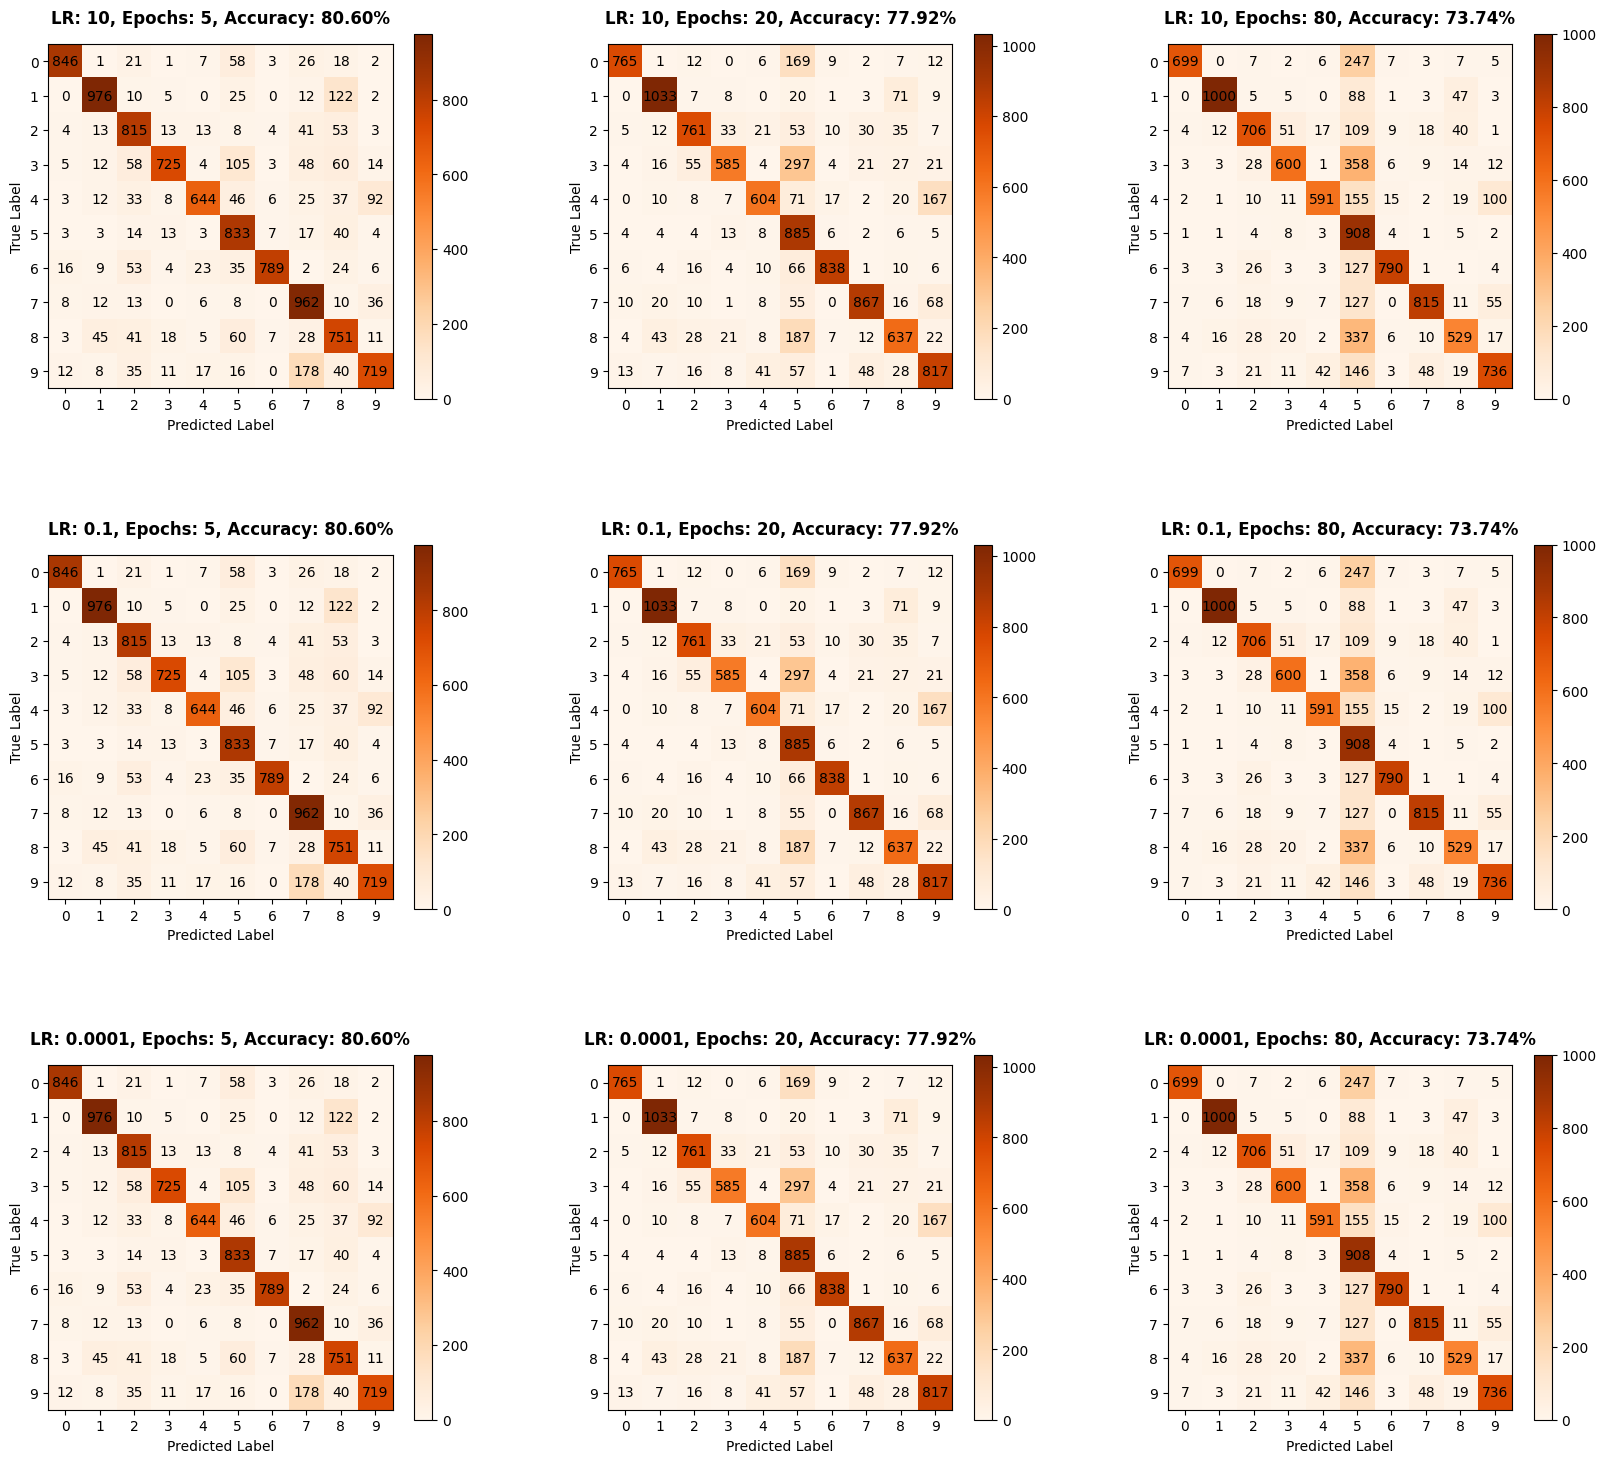

In [ ]:
# 1. Παραγωγή Καμπυλών Εκπαίδευσης (Training Curves)
plt.figure(figsize=(10, 6))
learning_rates = [10, 0.1, 0.0001]

for a in learning_rates:
    # Καλούμε τη συνάρτηση ΜΙΑ φορά για 80 εποχές!
    _, cost_history = training_ova(X_train_B, y_train_B, a=a, epochs=80)
    plt.plot(range(1, 81), cost_history, label=f'a = {a}')

plt.title("Training Curves (OvA - Scenario B)")
plt.xlabel("Epochs")
plt.ylabel("Total Training Mistakes")
plt.legend()
plt.grid(True)
plt.savefig("training_curves_ova_B.png")
plt.show()


# 2. Πίνακες Σύγχυσης & Αξιολόγηση (Grid Search)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους
epochs_list = [5, 20, 80]
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes_flat = axes.flatten()
plot_idx = 0

best_accuracy=0 #καλύτερο ποσοστό επιτυχίας
best_predictions=[] #καλύτερες προβλέψεις
best_params="" #καλύτερο learning rate και καλύτερο epochs

for a in learning_rates:
    for epochs in epochs_list:
        models, _ = training_ova(X_train_B, y_train_B, a, epochs)
        predictions = prediction_ova(models, X_test)

        #ποσοστά επιτυχίας
        correct=0
        for i in range(len(predictions)):
          if (predictions[i]==int(y_test_int[i])):
            correct+=1
        accuracy=(correct/len(predictions))*100
        print(f"Learning rate: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%")

        #κρατάμε το καλύτερο μοντέλο
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_predictions=predictions.copy()
            best_params=f"LR={a}, Epochs={epochs}"

        #πίνακες σύγχυσης
        confusion_matrix=np.zeros((10,10))

        for i in range(len(predictions)):
          true_val=y_test_int[i] #πραγματική τιμή
          pred_val=predictions[i] #προβλεπόμενη τιμή
          confusion_matrix[true_val][pred_val]+=1

        #δημιουργία γραφημάτων
        ax=axes_flat[plot_idx]
        im=ax.imshow(confusion_matrix, cmap='Oranges')

        title=f'LR: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%'
        ax.set_title(title, pad=15, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

        for row in range(10):
          for col in range(10):
            value=int(confusion_matrix[row,col])
            ax.text(col, row, value, va='center', ha='center')

        fig.colorbar(im, ax=ax)
        plot_idx+=1

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig("cm_ova_B", dpi=300, bbox_inches='tight')
plt.show()

LR=0.1, Epochs=80


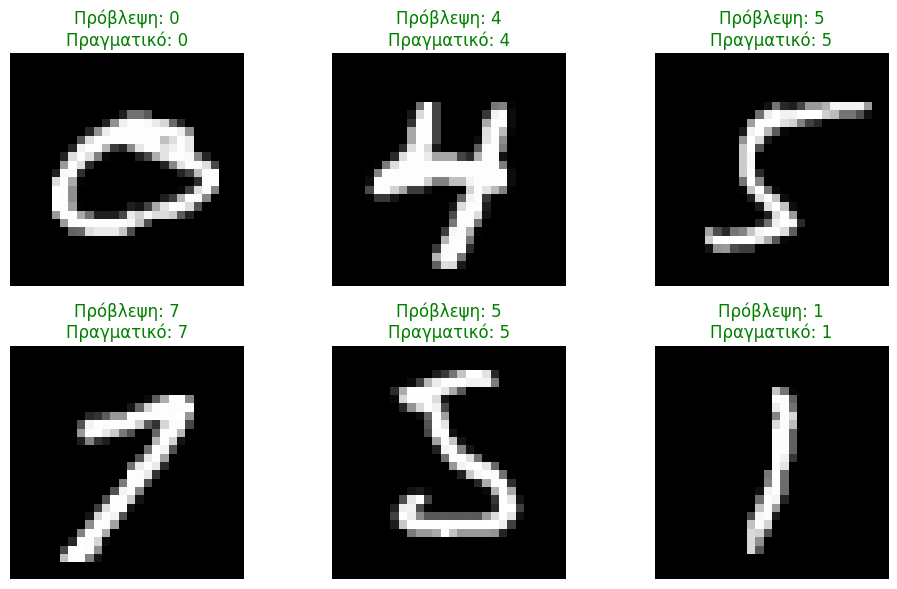

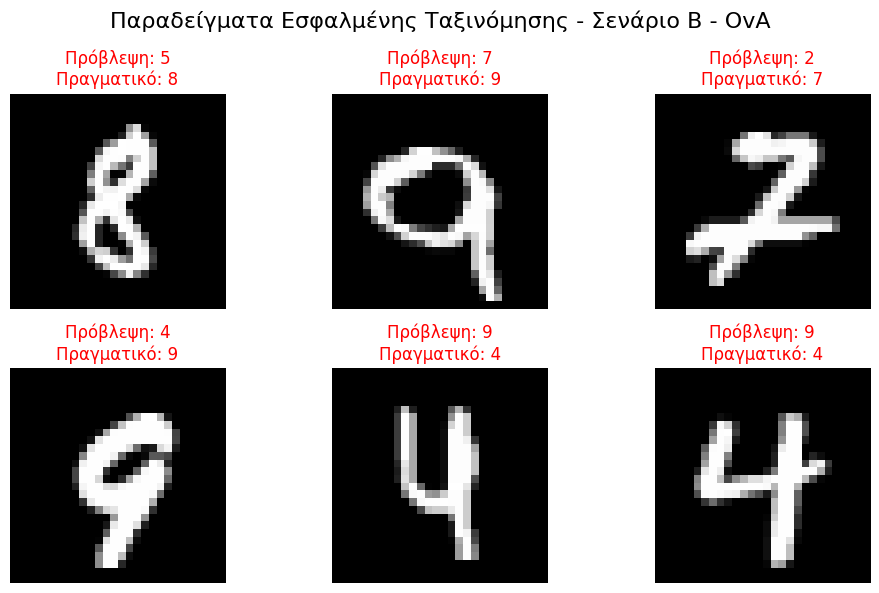

In [ ]:
#παραδείγματα ορθής και εσφαλμένης ταξινόμησης
print(best_params)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους

correct=[]
incorrect=[]

#διαχωρισμός δεικτών σε σωστά και λάθος
for i in range(len(best_predictions)):
    if best_predictions[i]==y_test_int[i]:
        correct.append(i)
    else:
        incorrect.append(i)

#επιλογή 6 τυχαίων παραδειγμάτων από κάθε κατηγορία
num_examples=6
np.random.seed(42) #κάθε φορά να βγάζει τα ίδια παραδείγματα
np.random.shuffle(correct)
np.random.shuffle(incorrect)

selected_correct=correct[:num_examples]
selected_incorrect=incorrect[:num_examples]

#ορθά παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Ορθής Ταξινόμησης - Σενάριο Β - OvA", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_correct):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="green")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("correct_ova_B")
plt.show()

print("\n"+ " "*60+"\n")

#εσφαλμένα παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Εσφαλμένης Ταξινόμησης - Σενάριο Β - OvA", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_incorrect):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="red")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("incorrect_ova_B")
plt.show()

# Γραμμικός Ταξινομητής με 10 εξόδους και softmax



---
Συνάρτηση Εκπαίδευσης

---





In [ ]:
def training_softmax(X_train, y_train, a, epochs):
    np.random.seed(42)

    W=np.zeros((10, 784)) #πίνκας 10x784 (10 κλάσεις, 784 pixels)
    b=np.zeros(10) #διάνυσμα 10 θέσεων

    loss_history=[0]*epochs

    y_train_int=y_train.astype(int) #μετατροπή ετικετών σε ακεραίους 0..9

    for epoch in range(epochs):
        #ανακάτεμα
        indices=np.arange(len(X_train))
        np.random.shuffle(indices)
        X_shuffled=X_train[indices]
        y_shuffled=y_train_int[indices]

        epoch_loss=0.0

        for x, y_true in zip(X_shuffled, y_shuffled):
          #υπολογισμός z
          z=np.dot(W, x) + b

          #υπολογισμός Softmax
          exp_z=np.exp(z-np.max(z))
          y_pred=exp_z/np.sum(exp_z)

          #υπολογισμός Λάθους
          epoch_loss += -np.log(y_pred[y_true]+1e-9)

          #δημιουργία του στόχου t (One-Hot Encoding)
          t=np.zeros(10)
          t[y_true]=1.0 #βάζουμε 1 μόνο στη θέση της σωστής κλάσης

          #υπολογισμός του Gradient
          error=y_pred-t

          #ανανέωση Βαρών W και b
          W=W-a*np.outer(error, x)
          b=b-a*error

        loss_history[epoch]=epoch_loss/len(X_train) #μέσο λάθος εποχής

    return W, b, loss_history

---
Συνάρτηση Πρόβλεψης

---





In [ ]:
def prediction_softmax(W, b, X_test):
    predictions=[]

    for x in X_test:
        z=np.dot(W, x)+b
        predictions.append(np.argmax(z))

    return predictions

---
Σενάριο Α

---





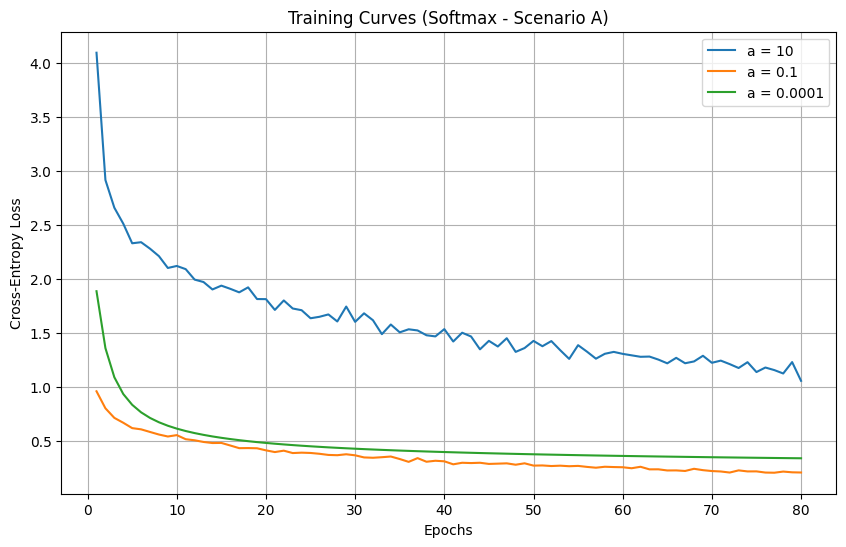

Learning rate: 10, Epochs: 5, Accuracy: 85.63%
Learning rate: 10, Epochs: 20, Accuracy: 87.93%
Learning rate: 10, Epochs: 80, Accuracy: 85.66%
Learning rate: 0.1, Epochs: 5, Accuracy: 88.76%
Learning rate: 0.1, Epochs: 20, Accuracy: 88.35%
Learning rate: 0.1, Epochs: 80, Accuracy: 87.08%
Learning rate: 0.0001, Epochs: 5, Accuracy: 84.71%
Learning rate: 0.0001, Epochs: 20, Accuracy: 87.68%
Learning rate: 0.0001, Epochs: 80, Accuracy: 90.00%


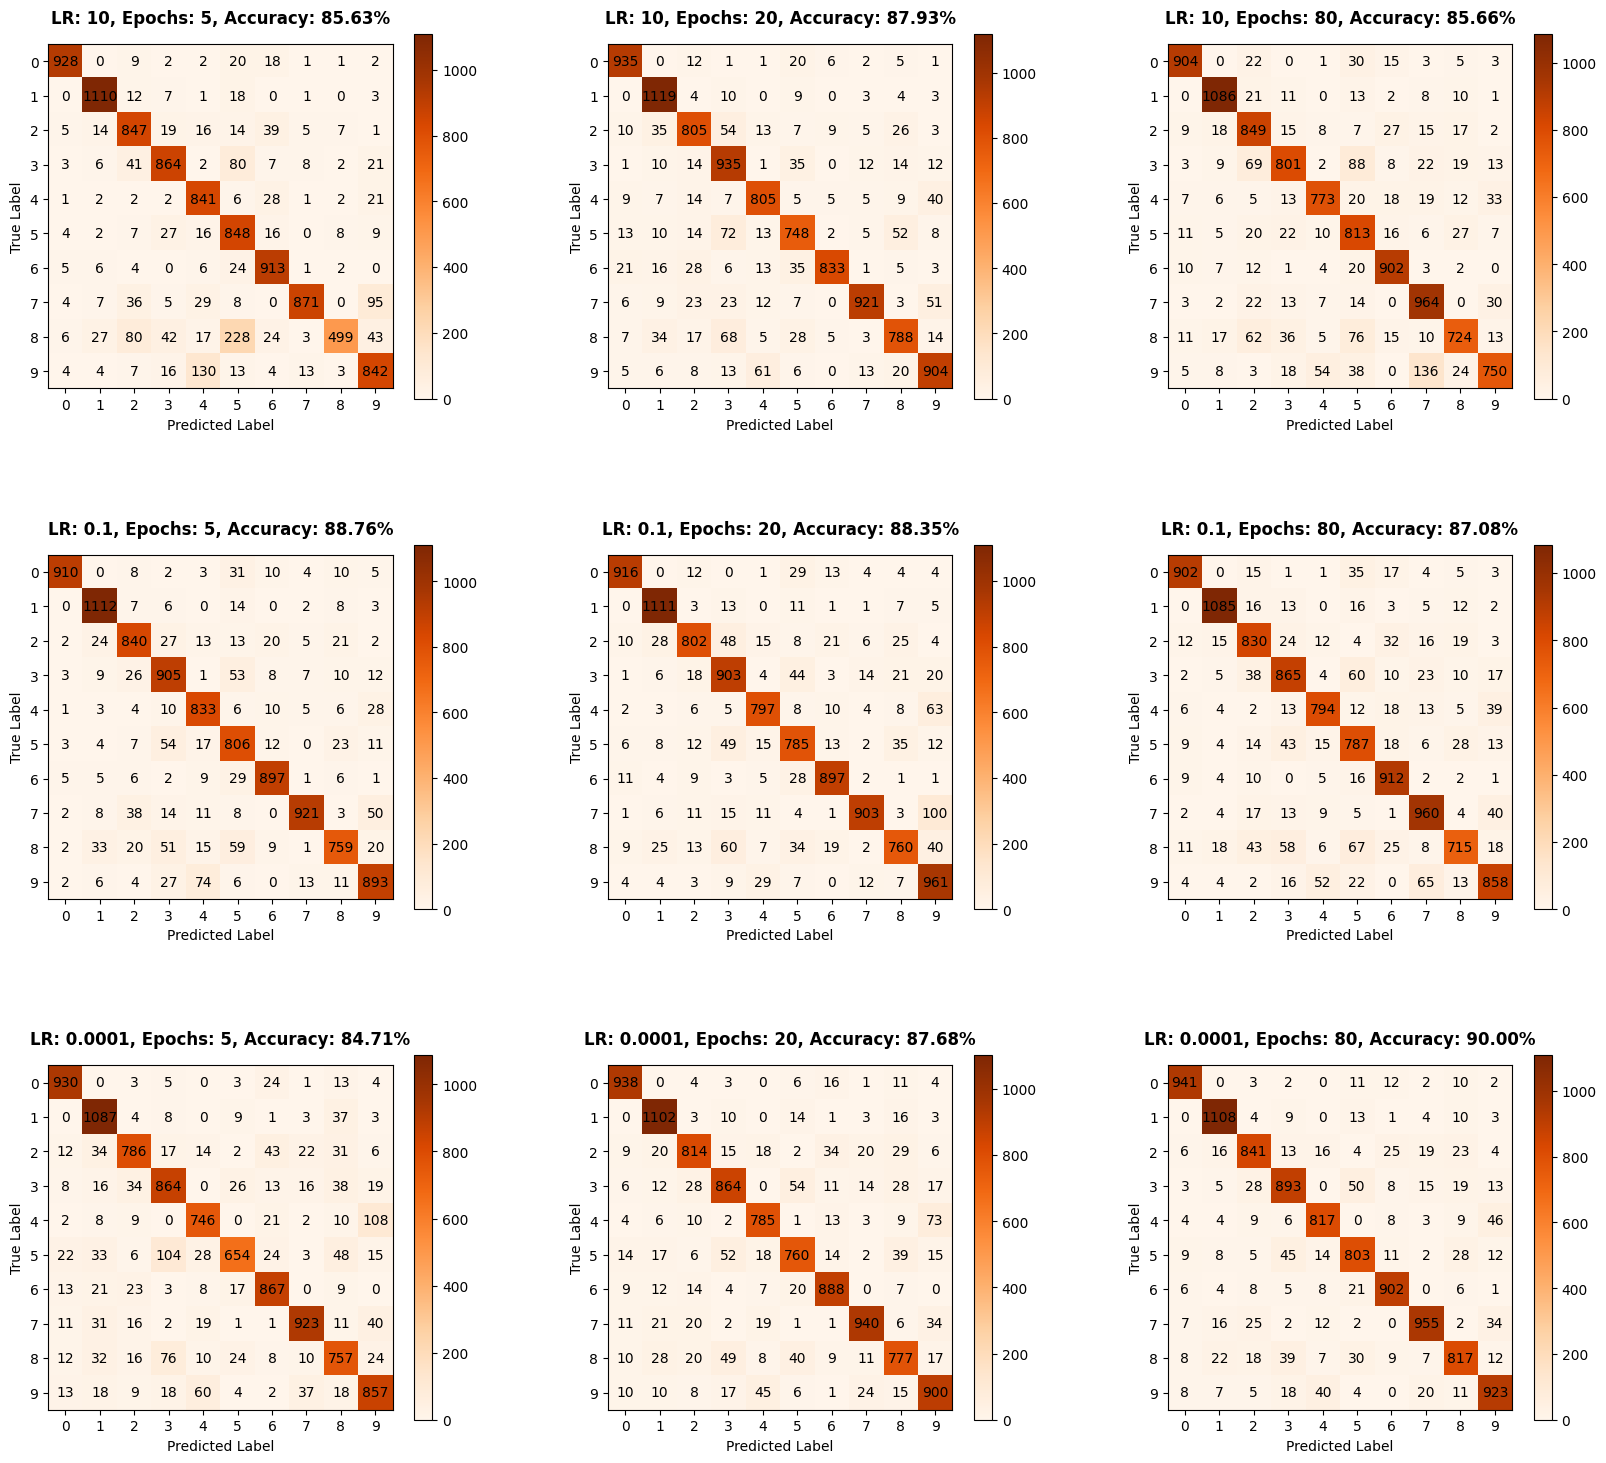

In [ ]:
#1. Παραγωγή Καμπυλών Εκπαίδευσης (Training Curves)
plt.figure(figsize=(10, 6))
learning_rates = [10, 0.1, 0.0001]

for a in learning_rates:
    W, b, cost_history = training_softmax(X_train_A, y_train_A, a, epochs=80)
    plt.plot(range(1, 81), cost_history, label=f'a = {a}')

plt.title("Training Curves (Softmax - Scenario A)")
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_curves_softmax_A.png")
plt.show()


#2. Πίνακες Σύγχυσης & Αξιολόγηση (Grid Search)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους
epochs_list = [5, 20, 80]
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes_flat = axes.flatten()
plot_idx = 0

best_accuracy=0 #καλύτερο ποσοστό επιτυχίας
best_predictions=[] #καλύτερες προβλέψεις
best_params="" #καλύτερο learning rate και καλύτερο epochs

for a in learning_rates:
    for epochs in epochs_list:
        W, b, cost_history = training_softmax(X_train_A, y_train_A, a, epochs)
        predictions = prediction_softmax(W, b, X_test)

        #ποσοστά επιτυχίας
        correct=0
        for i in range(len(predictions)):
          if (predictions[i]==int(y_test_int[i])):
            correct+=1
        accuracy=(correct/len(predictions))*100
        print(f"Learning rate: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%")

        #κρατάμε το καλύτερο μοντέλο
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_predictions=predictions.copy()
            best_params=f"LR={a}, Epochs={epochs}"

        #πίνακες σύγχυσης
        confusion_matrix=np.zeros((10,10))

        for i in range(len(predictions)):
          true_val=y_test_int[i] #πραγματική τιμή
          pred_val=predictions[i] #προβλεπόμενη τιμή
          confusion_matrix[true_val][pred_val]+=1

        #δημιουργία γραφημάτων
        ax=axes_flat[plot_idx]
        im=ax.imshow(confusion_matrix, cmap='Oranges')

        title=f'LR: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%'
        ax.set_title(title, pad=15, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

        for row in range(10):
          for col in range(10):
            value=int(confusion_matrix[row,col])
            ax.text(col, row, value, va='center', ha='center')

        fig.colorbar(im, ax=ax)
        plot_idx+=1

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig("cm_softmax_A", dpi=300, bbox_inches='tight')
plt.show()

LR=0.1, Epochs=80


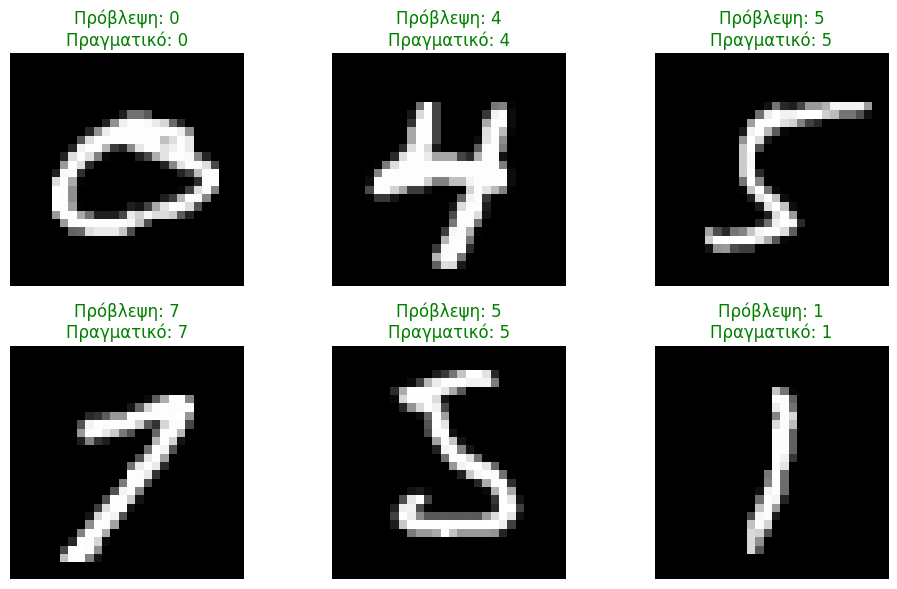

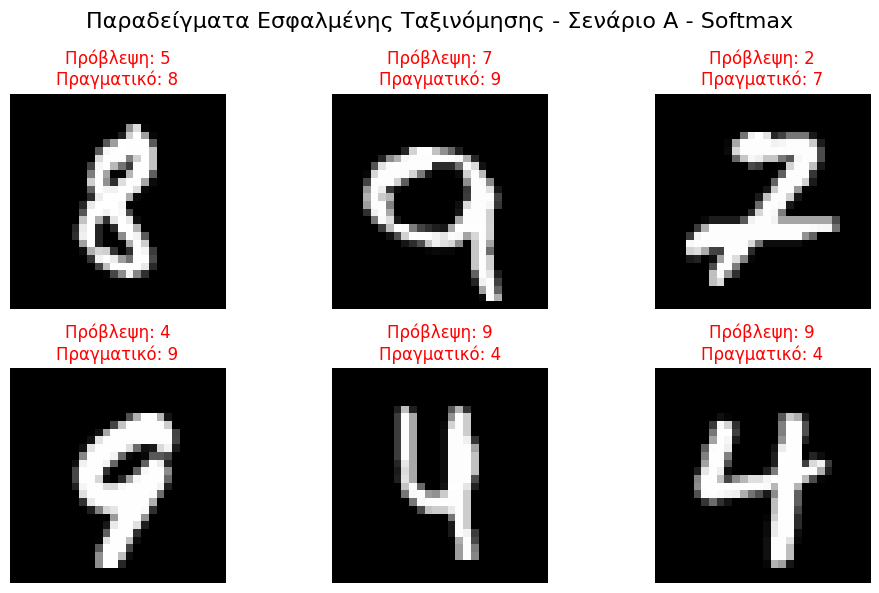

In [ ]:
#παραδείγματα ορθής και εσφαλμένης ταξινόμησης
print(best_params)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους

correct=[]
incorrect=[]

#διαχωρισμός δεικτών σε σωστά και λάθος
for i in range(len(best_predictions)):
    if best_predictions[i]==y_test_int[i]:
        correct.append(i)
    else:
        incorrect.append(i)

#επιλογή 6 τυχαίων παραδειγμάτων από κάθε κατηγορία
num_examples=6
np.random.seed(42) #κάθε φορά να βγάζει τα ίδια παραδείγματα
np.random.shuffle(correct)
np.random.shuffle(incorrect)

selected_correct=correct[:num_examples]
selected_incorrect=incorrect[:num_examples]

#ορθά παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Ορθής Ταξινόμησης - Σενάριο Α - Softmax", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_correct):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="green")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("correct_softmax_A")
plt.show()

print("\n"+ " "*60+"\n")

#εσφαλμένα παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Εσφαλμένης Ταξινόμησης - Σενάριο Α - Softmax", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_incorrect):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="red")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("incorrect_softmax_A")
plt.show()

---
Σενάριο Β

---





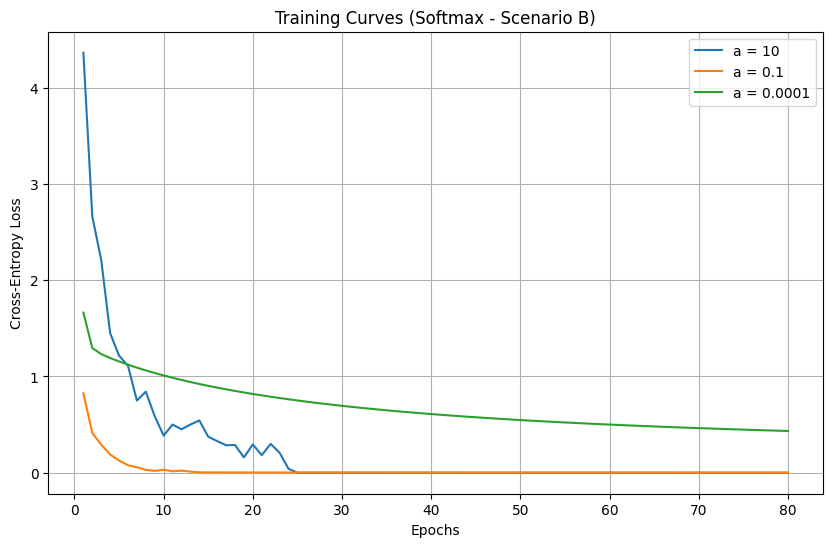

Learning rate: 10, Epochs: 5, Accuracy: 56.45%
Learning rate: 10, Epochs: 20, Accuracy: 75.47%
Learning rate: 10, Epochs: 80, Accuracy: 79.41%
Learning rate: 0.1, Epochs: 5, Accuracy: 76.27%
Learning rate: 0.1, Epochs: 20, Accuracy: 80.08%
Learning rate: 0.1, Epochs: 80, Accuracy: 80.14%
Learning rate: 0.0001, Epochs: 5, Accuracy: 9.37%
Learning rate: 0.0001, Epochs: 20, Accuracy: 30.33%
Learning rate: 0.0001, Epochs: 80, Accuracy: 66.05%


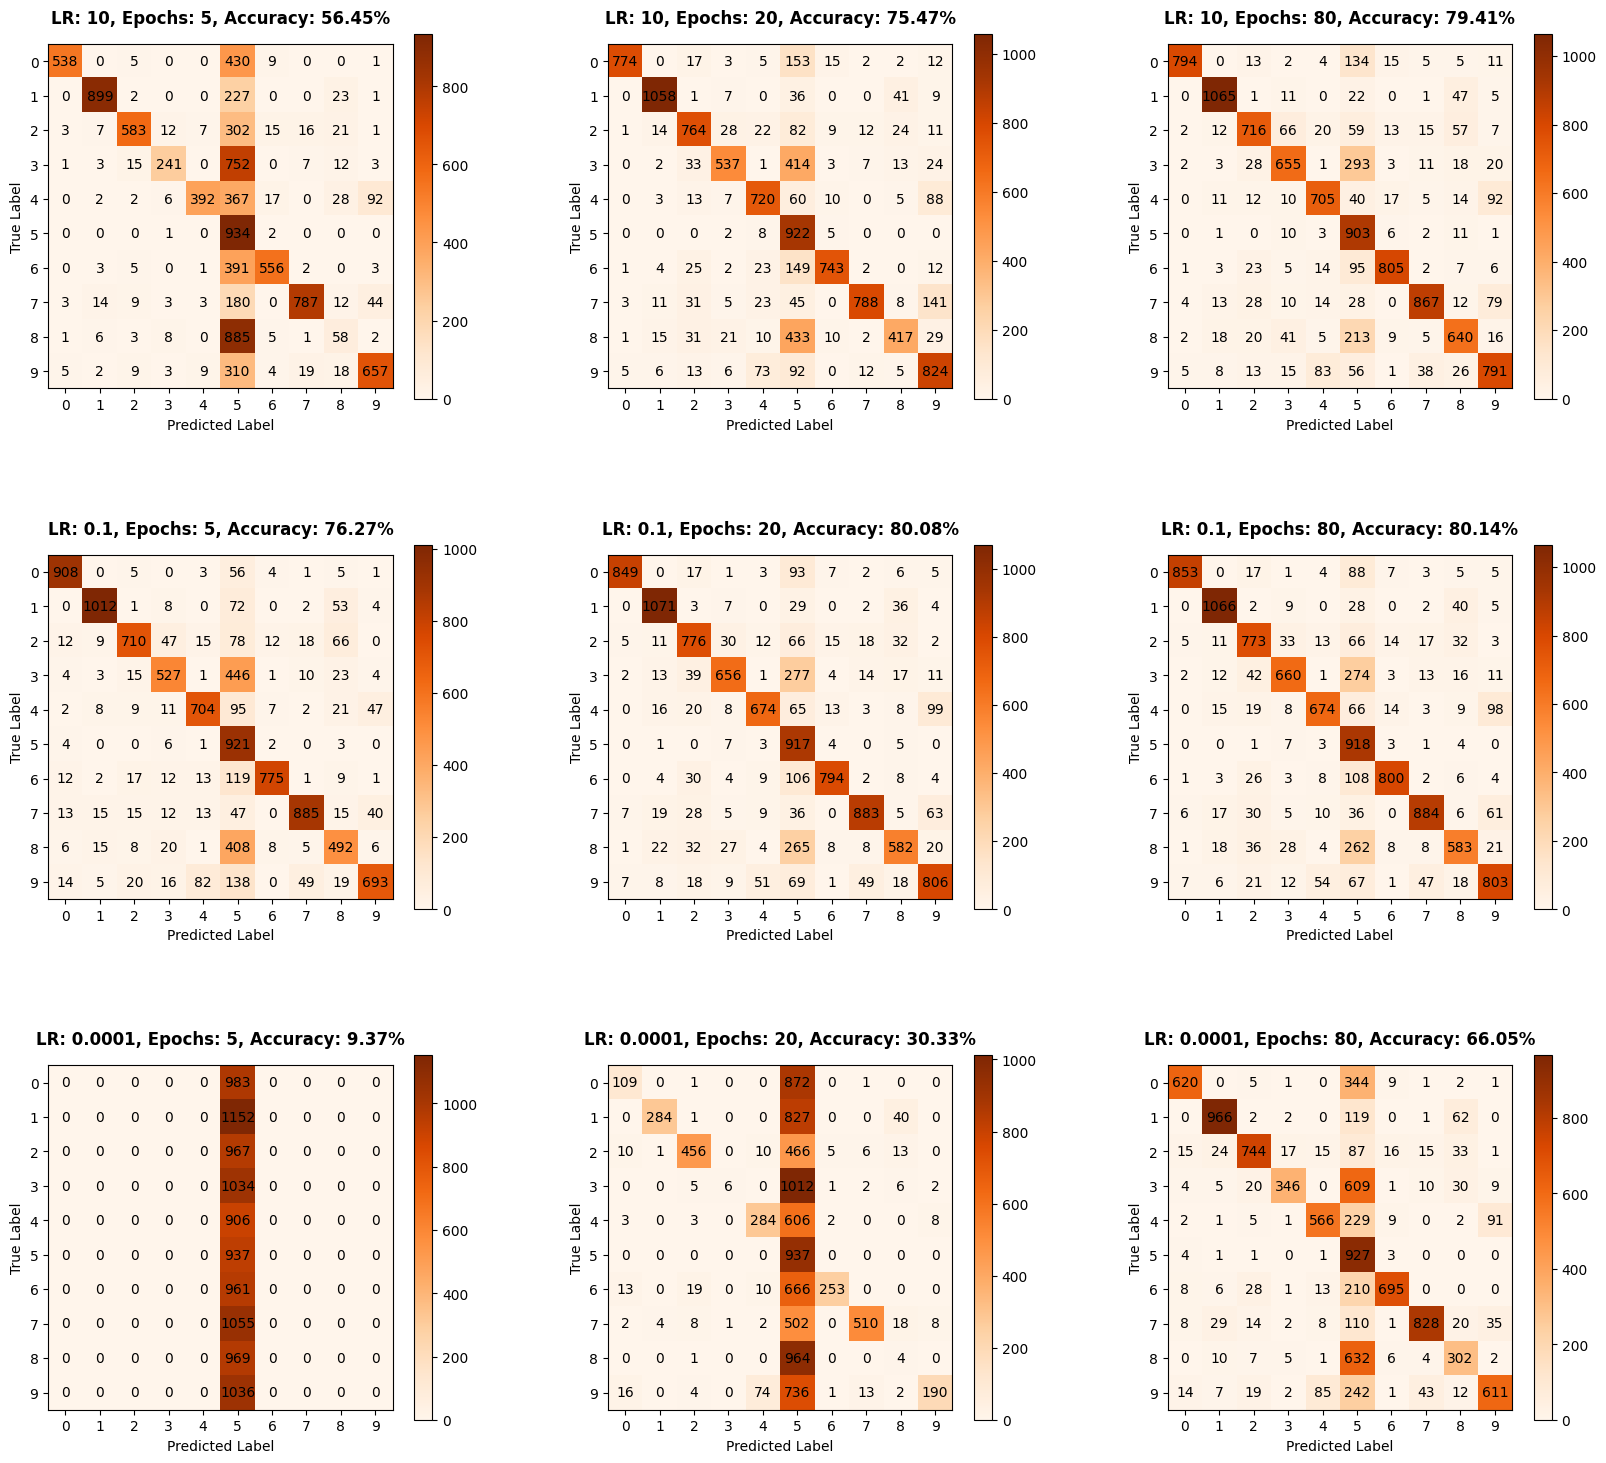

In [ ]:
# 1. Παραγωγή Καμπυλών Εκπαίδευσης (Training Curves)
plt.figure(figsize=(10, 6))
learning_rates = [10, 0.1, 0.0001]

for a in learning_rates:
    # Καλούμε τη συνάρτηση ΜΙΑ φορά για 80 εποχές!
    W, b, cost_history=training_softmax(X_train_B, y_train_B, a, epochs=80)
    plt.plot(range(1, 81), cost_history, label=f'a = {a}')

plt.title("Training Curves (Softmax - Scenario B)")
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_curves_softmax_B.png")
plt.show()


# 2. Πίνακες Σύγχυσης & Αξιολόγηση (Grid Search)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους
epochs_list = [5, 20, 80]
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes_flat = axes.flatten()
plot_idx = 0

best_accuracy=0 #καλύτερο ποσοστό επιτυχίας
best_predictions=[] #καλύτερες προβλέψεις
best_params="" #καλύτερο learning rate και καλύτερο epochs

for a in learning_rates:
    for epochs in epochs_list:
        W, b, cost_history = training_softmax(X_train_B, y_train_B, a, epochs)
        predictions = prediction_softmax(W, b, X_test)

        #ποσοστά επιτυχίας
        correct=0
        for i in range(len(predictions)):
          if (predictions[i]==int(y_test_int[i])):
            correct+=1
        accuracy=(correct/len(predictions))*100
        print(f"Learning rate: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%")

        #κρατάμε το καλύτερο μοντέλο
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_predictions=predictions.copy()
            best_params=f"LR={a}, Epochs={epochs}"

        #πίνακες σύγχυσης
        confusion_matrix=np.zeros((10,10))

        for i in range(len(predictions)):
          true_val=y_test_int[i] #πραγματική τιμή
          pred_val=predictions[i] #προβλεπόμενη τιμή
          confusion_matrix[true_val][pred_val]+=1

        #δημιουργία γραφημάτων
        ax=axes_flat[plot_idx]
        im=ax.imshow(confusion_matrix, cmap='Oranges')

        title=f'LR: {a}, Epochs: {epochs}, Accuracy: {accuracy:.2f}%'
        ax.set_title(title, pad=15, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))

        for row in range(10):
          for col in range(10):
            value=int(confusion_matrix[row,col])
            ax.text(col, row, value, va='center', ha='center')

        fig.colorbar(im, ax=ax)
        plot_idx+=1

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig("cm_softmax_B", dpi=300, bbox_inches='tight')
plt.show()

LR=0.1, Epochs=80


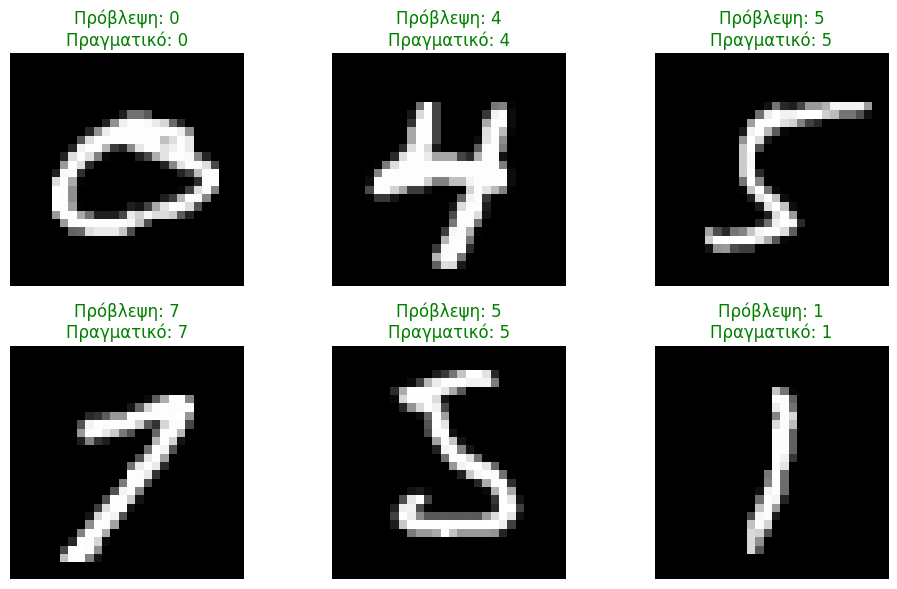

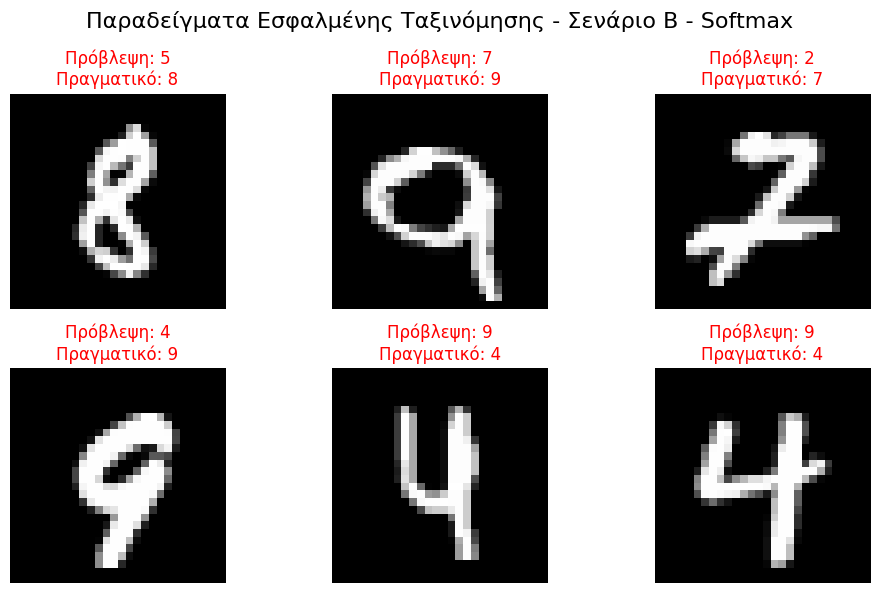

In [ ]:
#παραδείγματα ορθής και εσφαλμένης ταξινόμησης
print(best_params)
y_test_int=y_test.astype(int) #μετατροπή σε ακεραίους

correct=[]
incorrect=[]

#διαχωρισμός δεικτών σε σωστά και λάθος
for i in range(len(best_predictions)):
    if best_predictions[i]==y_test_int[i]:
        correct.append(i)
    else:
        incorrect.append(i)

#επιλογή 6 τυχαίων παραδειγμάτων από κάθε κατηγορία
num_examples=6
np.random.seed(42) #κάθε φορά να βγάζει τα ίδια παραδείγματα
np.random.shuffle(correct)
np.random.shuffle(incorrect)

selected_correct=correct[:num_examples]
selected_incorrect=incorrect[:num_examples]

#ορθά παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Ορθής Ταξινόμησης - Σενάριο Β - Softmax", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_correct):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="green")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("correct_softmax_B")
plt.show()

print("\n"+ " "*60+"\n")

#εσφαλμένα παραδείγματα
fig, axes=plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Παραδείγματα Εσφαλμένης Ταξινόμησης - Σενάριο Β - Softmax", fontsize=16)

axes_flat = axes.flatten() #μετατροπή 2x3 πίνακα σε μονοδιάστατο

for j, idx in enumerate(selected_incorrect):
    img=X_test[idx].reshape(28, 28) #μετατροπή των 784 pixels σε εικόνα 28x28
    axes_flat[j].imshow(img, cmap='gray')
    axes_flat[j].set_title(f"Πρόβλεψη: {best_predictions[idx]}\nΠραγματικό: {y_test_int[idx]}", color="red")
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("incorrect_softmax_B")
plt.show()